### Closing price prediction of a stock using data from the last 60 days via SVR

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import math 
import time 
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV

In [4]:
start_time = time.time()

In [5]:
# Load data
df = pd.read_csv('../Download data/data.csv', index_col=0, parse_dates=True)

# Display data
df

,close
date,
2015-01-02,205.43
2015-01-05,201.72
2015-01-06,199.82
2015-01-07,202.31
2015-01-08,205.90
...,...
2024-12-24,601.30
2024-12-26,601.34
2024-12-27,595.01


In [6]:
# Extract 'Close' prices as Dataframe
data = df[['close']].copy()

In [7]:
# Scale data between 0 and 1
scaler = MinMaxScaler((0,1))
scaled_data = scaler.fit_transform(data)

In [8]:
# Create sliding window sequences
window = 60
x, y = [], []
for i in range(window, len(scaled_data)):
    x.append(scaled_data[i-window:i,0])
    y.append(scaled_data[i,0])
x = np.array(x)
y = np.array(y)

In [9]:
# Split training and test sets
train_size = int(len(x) * 0.8)
x_train, x_test = x[:train_size], x[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [10]:
# Grid search for best hyperparameters
param_grid = {
    'C': [1, 100, 1000],
    'gamma': [0.01, 0.001, 0.0001],
    'epsilon': [0.01, 0.001, 0.0001]
}
grid_search = GridSearchCV(SVR(kernel='rbf'), param_grid, cv=3, scoring='neg_mean_squared_error')
grid_search.fit(x_train, y_train)

print("Best params:", grid_search.best_params_)

Best params: {'C': 1000, 'epsilon': 0.0001, 'gamma': 0.001}


In [11]:
# Use the best model
model = grid_search.best_estimator_
y_pred_scaled = model.predict(x_test).reshape(-1, 1)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))

In [12]:
# Metrics
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred))
mae = mean_absolute_error(y_test_inv, y_pred)
r2 = r2_score(y_test_inv, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

RMSE: 4.2878
MAE:  3.3916
R²:   0.9955


In [13]:
# Built train and valid with the temporal index
train = pd.DataFrame(df['close'][:train_size+window])
valid = pd.DataFrame(df['close'][train_size+window:])

# Align the predictions with the actual index
valid['Predictions'] = y_pred

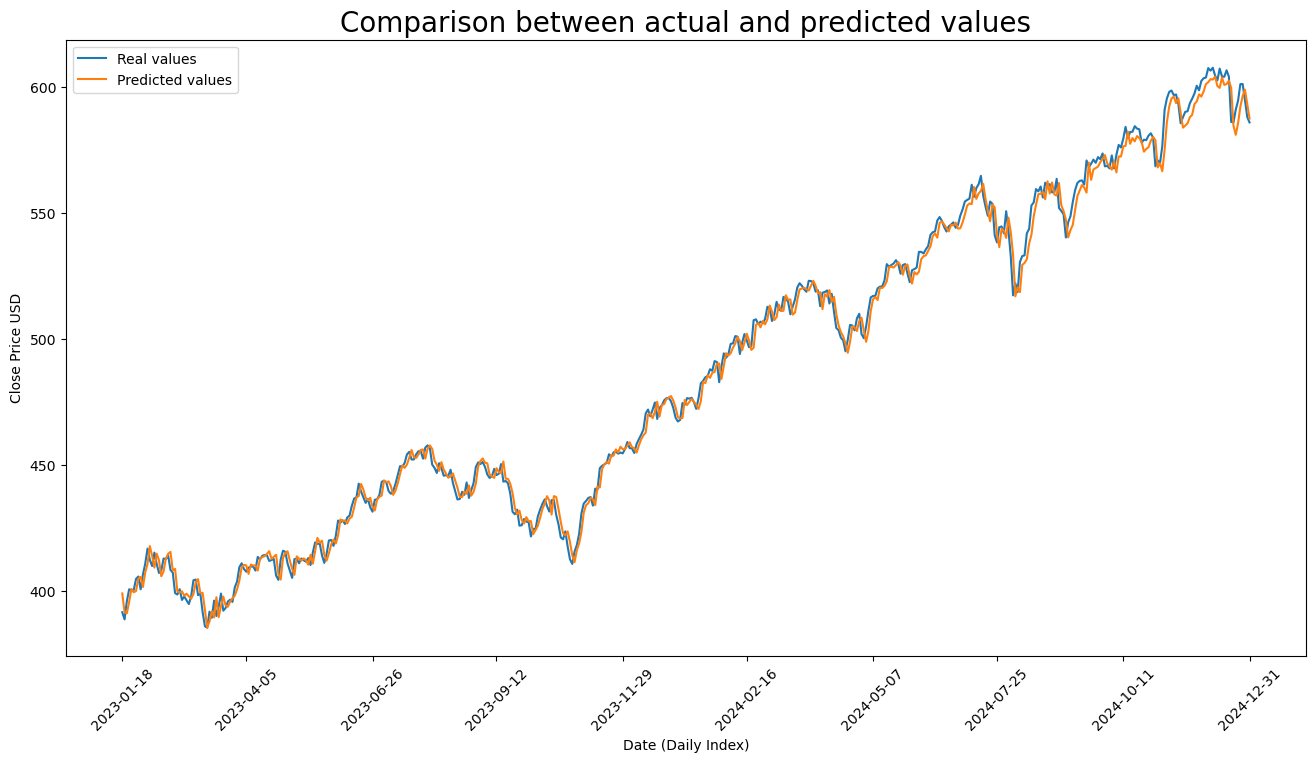

,close,Predictions
date,,
2023-01-18,391.49,398.958212
2023-01-19,388.64,391.545624
2023-01-20,395.88,391.096573
2023-01-23,400.63,395.653512
2023-01-24,400.20,400.750874
...,...,...
2024-12-24,601.30,592.353063
2024-12-26,601.34,596.545489
2024-12-27,595.01,599.083909


In [14]:
# Plot & display actual vs predicted values
plt.figure(figsize=(16, 8))
plt.plot(y_test_inv, label='Real values')  
plt.plot(y_pred, label='Predicted values')            
plt.title('Comparison between actual and predicted values', fontsize=20)
plt.xlabel('Date (Daily Index)')
plt.xticks(ticks=np.linspace(0, len(valid.index)-1, 10, dtype=int),  
           labels=[valid.index[i].strftime('%Y-%m-%d') for i in np.linspace(0, len(valid.index)-1, 10, dtype=int)],
           rotation=45)
plt.ylabel('Close Price USD')
plt.legend()
plt.show()

valid

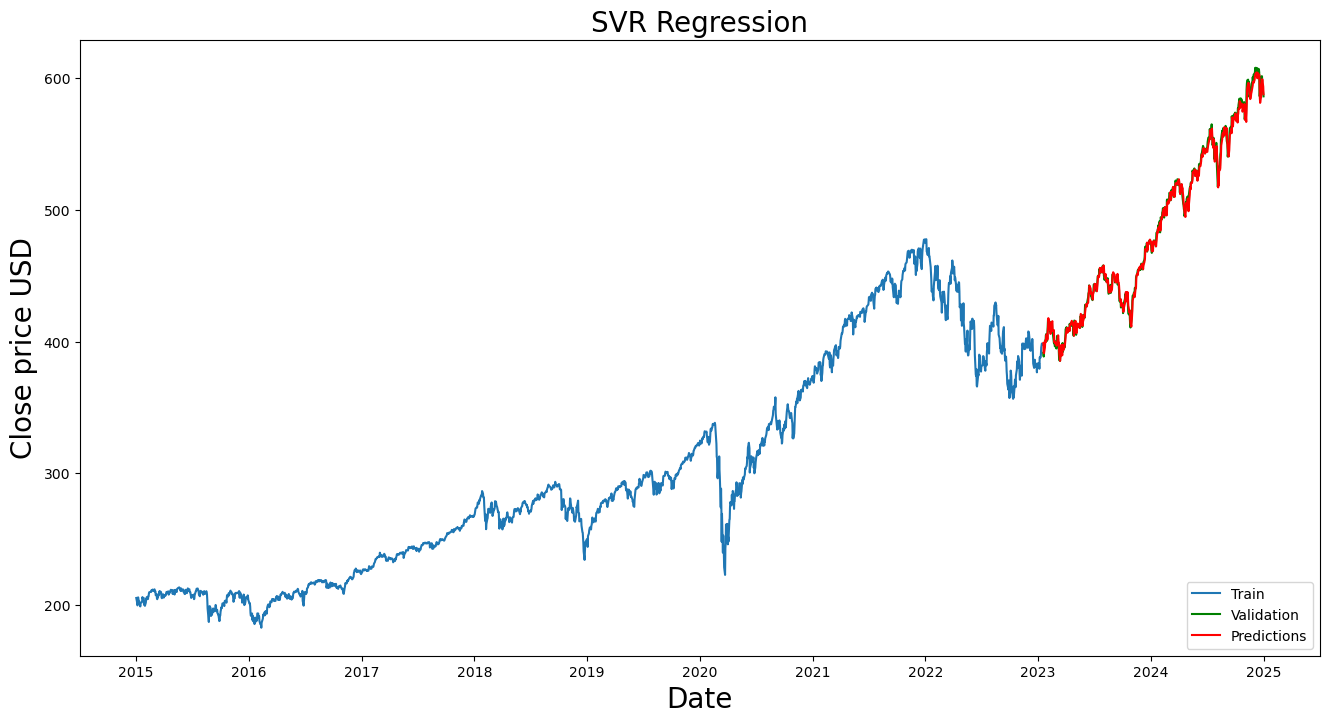

In [15]:
# Plot training, validation and predictions
plt.figure(figsize=(16,8))
plt.title('SVR Regression', fontsize=20)
plt.xlabel('Date', fontsize=20)
plt.ylabel('Close price USD', fontsize=20)
plt.plot(train['close'], label='Train')
plt.plot(valid['close'], color='green', label='Validation')
plt.plot(valid['Predictions'], color='red', label='Predictions')
plt.legend(loc='lower right')
plt.show()

In [16]:
end_time = time.time()
elapsed_time = end_time - start_time

print(f"Execution time: {elapsed_time:.2f} seconds")

Execution time: 18.36 seconds
